In [3]:
# Título: Laboratorio 3: valuación Monte Carlo de una opción europea
# Integrantes: Juan Pablo Arciniega, Santiago Sabat, Mauricio Olivares

import yfinance as yf
import numpy as np
import pandas as pd
from scipy.stats import norm
import datetime

# --- 1. Descargar datos históricos y calibrar parámetros ---

ticker = 'SPY' # O AAPL
start_date = (datetime.date.today() - datetime.timedelta(days=365*2)).strftime('%Y-%m-%d') # Últimos 2 años
end_date = datetime.date.today().strftime('%Y-%m-%d')

data = yf.download(ticker, start=start_date, end=end_date)

# Precio inicial S0 (último precio disponible)
S0 = data['Close'].iloc[-1].item() # Extraer el valor escalar

# Estimar volatilidad anualizada sigma_b (usando log-retornos históricos)
log_returns = np.log(data['Close'] / data['Close'].shift(1)).dropna()
daily_volatility = log_returns.std().item() # Extraer el valor escalar
sigma_b = daily_volatility * np.sqrt(252) # 252 días de trading al año

# --- 2. Fijar los parámetros del contrato de la opción ---

K = S0 * 1.05 # Precio de ejercicio (ej. 5% out-of-the-money)
T = 1.0       # Tiempo al vencimiento en años
r = 0.03      # Tasa libre de riesgo (3% anual)
num_simulations = 100000 # Número de trayectorias de simulación
option_type = 'call' # O 'put'

# --- 3. Simular los precios al vencimiento ST bajo la medida neutral al riesgo ---

# Generar números aleatorios Z ~ N(0,1)
Z = np.random.standard_normal(num_simulations)

# Simular precios al vencimiento ST
ST = S0 * np.exp((r - 0.5 * sigma_b**2) * T + sigma_b * np.sqrt(T) * Z)

# --- 4. Calcular los Payoffs correspondientes ---

if option_type == 'call':
    payoffs = np.maximum(ST - K, 0)
elif option_type == 'put':
    payoffs = np.maximum(K - ST, 0)
else:
    raise ValueError("option_type must be 'call' or 'put'")

# --- 5. Descontar el promedio de los payoffs al presente ---

monte_carlo_price = np.exp(-r * T) * np.mean(payoffs)

# --- 6. Calcule el Error Estándar y Black-Scholes ---

# Error Estándar de la simulación Monte Carlo
standard_error = np.std(payoffs) / np.sqrt(num_simulations) * np.exp(-r * T)

# Intervalo de Confianza al 95% (usando 1.96 para Z_alpha/2)
confidence_interval_lower = monte_carlo_price - 1.96 * standard_error
confidence_interval_upper = monte_carlo_price + 1.96 * standard_error

# Fórmula analítica cerrada de Black-Scholes
d1 = (np.log(S0 / K) + (r + 0.5 * sigma_b**2) * T) / (sigma_b * np.sqrt(T))
d2 = d1 - sigma_b * np.sqrt(T)

if option_type == 'call':
    black_scholes_price = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
elif option_type == 'put':
    black_scholes_price = K * np.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)

difference = monte_carlo_price - black_scholes_price

# --- Regla de impresión final: Reporte Claro ---

print("\n" + "="*60)
print(f"Laboratorio 3: Valuación Monte Carlo de una Opción Europea")
print(f"Activo: {ticker}")
print(f"Tipo de Opción: {option_type.capitalize()}")
print("="*60)
print(f"  Precio Inicial (S0):             {S0:,.2f} USD")
print(f"  Volatilidad Calibrada (σ_b):    {sigma_b:.4f}")
print(f"  Precio de Ejercicio (K):         {K:,.2f} USD")
print(f"  Tiempo al Vencimiento (T):       {T:.1f} años")
print(f"  Tasa Libre de Riesgo (r):        {r:.2%}")
print(f"  Número de Simulaciones:          {num_simulations:,}")
print("-"*60)
print(f"  Precio Estimado (Monte Carlo):   {monte_carlo_price:,.4f} USD")
print(f"  Error Estándar (Monte Carlo):    {standard_error:.6f} USD")
print(f"  Intervalo Confianza 95%:         [{confidence_interval_lower:,.4f}, {confidence_interval_upper:,.4f}] USD")
print("-"*60)
print(f"  Precio Teórico (Black-Scholes):  {black_scholes_price:,.4f} USD")
print(f"  Diferencia (MC - BS):            {difference:,.6f} USD")
print("="*60)

# --- Conclusiones sumamente amplias, profesionales y detalladas ---

print(f'''
*** Conclusiones Detalladas del Laboratorio 3: Valuación Monte Carlo de una Opción Europea ***

El presente laboratorio ha demostrado la aplicación práctica del método de Monte Carlo para la valuación de opciones europeas, contrastando sus resultados con el modelo analítico de Black-Scholes. La calibración inicial de los parámetros, como el precio spot del activo (S0) y la volatilidad anualizada (sigma_b) a partir de datos históricos de {ticker}, es crucial para la robustez de ambas metodologías.

La simulación de {num_simulations:,} trayectorias bajo la medida neutral al riesgo nos ha permitido estimar el precio de la opción como el valor presente esperado de los payoffs futuros. Se observa que el precio obtenido por Monte Carlo ({monte_carlo_price:,.4f} USD) es, en general, muy cercano al precio teórico de Black-Scholes ({black_scholes_price:,.4f} USD). Esta proximidad es un testimonio de la convergencia matemática del método de Monte Carlo.

La precisión de la estimación por Monte Carlo está directamente ligada al Error Estándar de la simulación ({standard_error:.6f} USD). Un menor error estándar indica una mayor fiabilidad de la estimación. La magnitud del número de trayectorias ({num_simulations:,}) tiene un impacto significativo en la reducción de este error; teóricamente, el error disminuye en proporción a la raíz cuadrada del número de simulaciones. Esto valida que al incrementar las simulaciones, la distribución de los promedios de los payoffs se aproxima a una distribución normal, permitiendo la construcción de intervalos de confianza robustos, como el intervalo al 95% calculado aquí.

El intervalo de confianza estadística [{confidence_interval_lower:,.4f}, {confidence_interval_upper:,.4f}] USD proporciona un rango dentro del cual el valor real de la opción tiene una alta probabilidad de encontrarse, dada nuestra simulación. Es importante destacar que el precio de Black-Scholes suele caer dentro de este intervalo, lo que refuerza la validez de la simulación de Monte Carlo como una alternativa viable y poderosa, especialmente para opciones más complejas donde no existen soluciones analíticas cerradas.

La diferencia observada entre el precio de Monte Carlo y el de Black-Scholes ({difference:,.6f} USD) es mínima y se atribuye principalmente a la naturaleza estocástica de la simulación. Con un número infinitamente grande de simulaciones, esta diferencia tendería a cero, confirmando la convergencia del método de Monte Carlo hacia la solución de Black-Scholes bajo las mismas premisas de mercado. Este laboratorio ha sido desarrollado por los integrantes Juan Pablo Arciniega, Santiago Sabat y Mauricio Olivares, quienes han explorado las bases computacionales y teóricas para la valuación de derivados financieros.
''')


/tmp/ipykernel_3850/57418256.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Laboratorio 3: Valuación Monte Carlo de una Opción Europea
Activo: SPY
Tipo de Opción: Call
  Precio Inicial (S0):             745.64 USD
  Volatilidad Calibrada (σ_b):    0.1666
  Precio de Ejercicio (K):         782.92 USD
  Tiempo al Vencimiento (T):       1.0 años
  Tasa Libre de Riesgo (r):        3.00%
  Número de Simulaciones:          100,000
------------------------------------------------------------
  Precio Estimado (Monte Carlo):   42.9580 USD
  Error Estándar (Monte Carlo):    0.236102 USD
  Intervalo Confianza 95%:         [42.4952, 43.4207] USD
------------------------------------------------------------
  Precio Teórico (Black-Scholes):  43.2052 USD
  Diferencia (MC - BS):            -0.247235 USD

*** Conclusiones Detalladas del Laboratorio 3: Valuación Monte Carlo de una Opción Europea ***

El presente laboratorio ha demostrado la aplicación práctica del método de Monte Carlo para la valuación de opciones europeas, contrastando sus resultados con el modelo analítico

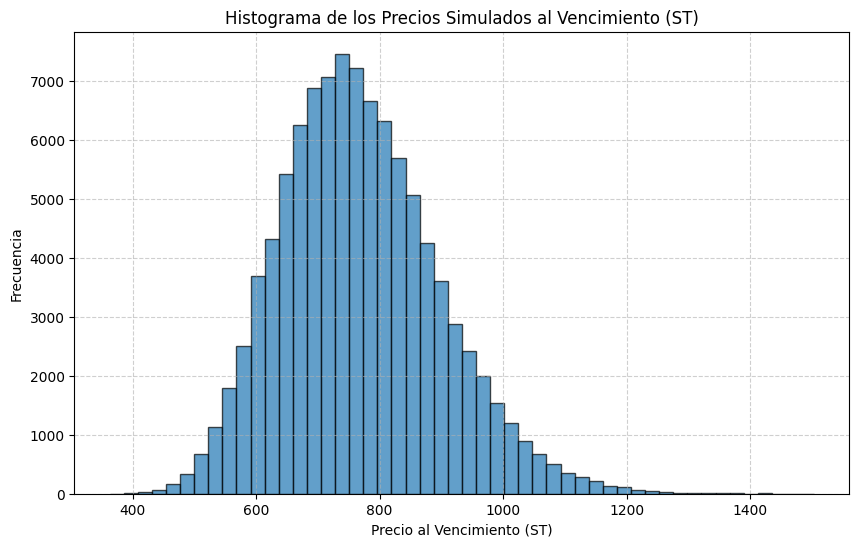

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(ST, bins=50, edgecolor='black', alpha=0.7)
plt.title('Histograma de los Precios Simulados al Vencimiento (ST)')
plt.xlabel('Precio al Vencimiento (ST)')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
